In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit

# Optional: nicer plot defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

In [5]:
file_path = "nbaallelo.csv"  
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (126314, 23)
   gameorder       game_id lg_id  _iscopy  year_id  date_game  seasongame  \
0          1  194611010TRH   NBA        0     1947  11/1/1946           1   
1          1  194611010TRH   NBA        1     1947  11/1/1946           1   
2          2  194611020CHS   NBA        0     1947  11/2/1946           1   
3          2  194611020CHS   NBA        1     1947  11/2/1946           2   
4          3  194611020DTF   NBA        0     1947  11/2/1946           1   

   is_playoffs team_id  fran_id  ...  win_equiv  opp_id  opp_fran  opp_pts  \
0            0     TRH  Huskies  ...  40.294830     NYK    Knicks       68   
1            0     NYK   Knicks  ...  41.705170     TRH   Huskies       66   
2            0     CHS    Stags  ...  42.012257     NYK    Knicks       47   
3            0     NYK   Knicks  ...  40.692783     CHS     Stags       63   
4            0     DTF  Falcons  ...  38.864048     WSC  Capitols       50   

   opp_elo_i  opp_elo_n  game_location  game_res

In [6]:
# Parse date
df["date_game"] = pd.to_datetime(df["date_game"], errors="coerce")

# Sort chronologically
df = df.sort_values(["date_game", "gameorder"]).reset_index(drop=True)

# Drop obvious non-modeling copy column if present
if "_iscopy" in df.columns:
    df = df.drop(columns=["_iscopy"])

# Standardize game_location
# Typical values are H, A, N, sometimes missing
df["game_location"] = df["game_location"].fillna("N").astype(str).str.upper().str.strip()

valid_locations = {"H", "A", "N"}
df.loc[~df["game_location"].isin(valid_locations), "game_location"] = "N"

# Basic row checks
print("\nMissing dates:", df["date_game"].isna().sum())
print("Game location counts:\n", df["game_location"].value_counts(dropna=False))
print("Year range:", df["year_id"].min(), "to", df["year_id"].max())


Missing dates: 0
Game location counts:
 game_location
H    63138
A    63138
N       38
Name: count, dtype: int64
Year range: 1947 to 2015


In [7]:
print("\nData types:\n")
print(df.dtypes)

print("\nMissing values by column:\n")
missing_summary = (
    df.isna().sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(df)
print(missing_summary.head(20))

print("\nDuplicate rows:", df.duplicated().sum())

# Should be ~2 rows per game_id if dataset is in team-perspective format
game_rows = df.groupby("game_id").size().value_counts().sort_index()
print("\nRows per game_id:\n", game_rows)


Data types:

gameorder                 int64
game_id                  object
lg_id                    object
year_id                   int64
date_game        datetime64[ns]
seasongame                int64
is_playoffs               int64
team_id                  object
fran_id                  object
pts                       int64
elo_i                   float64
elo_n                   float64
win_equiv               float64
opp_id                   object
opp_fran                 object
opp_pts                   int64
opp_elo_i               float64
opp_elo_n               float64
game_location            object
game_result              object
forecast                float64
notes                    object
dtype: object

Missing values by column:

               missing_count  missing_pct
notes                 120890     0.957059
game_id                    0     0.000000
forecast                   0     0.000000
game_result                0     0.000000
game_location              0  

In [8]:
candidate_cols = [
    "gameorder", "game_id", "year_id", "date_game", "seasongame", "is_playoffs",
    "team_id", "fran_id", "pts", "elo_i", "elo_n",
    "opp_id", "opp_fran", "opp_pts", "opp_elo_i", "opp_elo_n",
    "game_location", "game_result", "forecast"
]

existing_cols = [c for c in candidate_cols if c in df.columns]
df = df[existing_cols].copy()

print("Trimmed shape:", df.shape)
print(df.head())

Trimmed shape: (126314, 19)
   gameorder       game_id  year_id  date_game  seasongame  is_playoffs  \
0          1  194611010TRH     1947 1946-11-01           1            0   
1          1  194611010TRH     1947 1946-11-01           1            0   
2          2  194611020CHS     1947 1946-11-02           1            0   
3          2  194611020CHS     1947 1946-11-02           2            0   
4          3  194611020DTF     1947 1946-11-02           1            0   

  team_id  fran_id  pts      elo_i      elo_n opp_id  opp_fran  opp_pts  \
0     TRH  Huskies   66  1300.0000  1293.2767    NYK    Knicks       68   
1     NYK   Knicks   68  1300.0000  1306.7233    TRH   Huskies       66   
2     CHS    Stags   63  1300.0000  1309.6521    NYK    Knicks       47   
3     NYK   Knicks   47  1306.7233  1297.0712    CHS     Stags       63   
4     DTF  Falcons   33  1300.0000  1279.6189    WSC  Capitols       50   

   opp_elo_i  opp_elo_n game_location game_result  forecast  
0  1300.

In [9]:
UPSET_THRESHOLD = 0.40

df["win"] = (df["game_result"] == "W").astype(int)
df["upset"] = ((df["forecast"] <= UPSET_THRESHOLD) & (df["win"] == 1)).astype(int)

print("Overall upset rate:", df["upset"].mean().round(4))
print(df[["forecast", "win", "upset"]].head(10))

Overall upset rate: 0.0939
   forecast  win  upset
0  0.640065    0      0
1  0.359935    1      1
2  0.631101    1      0
3  0.368899    0      0
4  0.640065    0      0
5  0.359935    1      1
6  0.359935    0      0
7  0.640065    1      0
8  0.359935    0      0
9  0.640065    1      0


In [10]:
df["elo_gap"] = df["elo_i"] - df["opp_elo_i"]
df["is_home"] = (df["game_location"] == "H").astype(int)
df["is_away"] = (df["game_location"] == "A").astype(int)
df["is_neutral"] = (df["game_location"] == "N").astype(int)

# Games played so far proxy:
# seasongame is already in the dataset; keep it
# You can also create cumulative franchise games if desired
df["franchise_game_number"] = df.groupby("fran_id").cumcount() + 1

In [11]:
df["point_diff"] = df["pts"] - df["opp_pts"]
df["elo_delta"] = df["elo_n"] - df["elo_i"]

# Sort again for safety before grouped rolling
df = df.sort_values(["fran_id", "date_game", "gameorder"]).reset_index(drop=True)

In [12]:
def add_team_rolling_features(data, group_col="fran_id"):
    data = data.copy()
    
    # Ensure correct order within each team history
    data = data.sort_values([group_col, "date_game", "gameorder"]).reset_index(drop=True)
    
    grouped = data.groupby(group_col, group_keys=False)

    # Shifted series so current game never leaks into its own features
    data["win_lag1"] = grouped["win"].shift(1)
    data["point_diff_lag1"] = grouped["point_diff"].shift(1)
    data["elo_delta_lag1"] = grouped["elo_delta"].shift(1)
    data["elo_i_lag1"] = grouped["elo_i"].shift(1)
    data["opp_elo_i_lag1"] = grouped["opp_elo_i"].shift(1)

    # Rolling win rate
    for w in [5, 10]:
        data[f"win_rolling_{w}"] = (
            grouped["win"]
            .shift(1)
            .rolling(window=w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

    # Rolling average point differential
    for w in [5, 10]:
        data[f"pointdiff_rolling_{w}"] = (
            grouped["point_diff"]
            .shift(1)
            .rolling(window=w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

    # Rolling point diff volatility
    data["pointdiff_std_10"] = (
        grouped["point_diff"]
        .shift(1)
        .rolling(window=10, min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
    )

    # Rolling Elo change
    for w in [5, 10]:
        data[f"elo_delta_rolling_{w}"] = (
            grouped["elo_delta"]
            .shift(1)
            .rolling(window=w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

    # Recent opponent quality
    data["opp_elo_rolling_10"] = (
        grouped["opp_elo_i"]
        .shift(1)
        .rolling(window=10, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # Elo slope / momentum using diff of prior elo_i
    data["elo_i_diff_1"] = grouped["elo_i"].shift(1) - grouped["elo_i"].shift(2)
    data["elo_i_diff_3_mean"] = (
        grouped["elo_i"]
        .shift(1)
        .diff()
        .rolling(window=3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # Prior game count per franchise before current game
    data["prior_games_count"] = grouped.cumcount()

    return data

df = add_team_rolling_features(df, group_col="fran_id")

print(df.head(20))

    gameorder       game_id  year_id  date_game  seasongame  is_playoffs  \
0         351  194711120WSC     1948 1947-11-12           1            0   
1         352  194711130BLB     1948 1947-11-13           2            0   
2         358  194711150CHS     1948 1947-11-15           3            0   
3         365  194711200BLB     1948 1947-11-20           4            0   
4         369  194711210BOS     1948 1947-11-21           5            0   
5         370  194711220BLB     1948 1947-11-22           6            0   
6         378  194711270PRO     1948 1947-11-27           7            0   
7         381  194711290STB     1948 1947-11-29           8            0   
8         384  194712020BOS     1948 1947-12-02           9            0   
9         387  194712030GSW     1948 1947-12-03          10            0   
10        388  194712040BLB     1948 1947-12-04          11            0   
11        390  194712060CHS     1948 1947-12-06          12            0   
12        39

In [14]:
rolling_fill_map = {
    "win_rolling_5": 0.5,
    "win_rolling_10": 0.5,
    "pointdiff_rolling_5": 0.0,
    "pointdiff_rolling_10": 0.0,
    "elo_delta_rolling_5": 0.0,
    "elo_delta_rolling_10": 0.0,
    "elo_i_diff_1": 0.0,
    "elo_i_diff_3_mean": 0.0,
    "opp_elo_rolling_10": df["opp_elo_i"].mean(),
}

for col, fill_value in rolling_fill_map.items():
    if col in df.columns:
        df[col] = df[col].fillna(fill_value)

if "pointdiff_std_10" in df.columns:
    df["pointdiff_std_10"] = df["pointdiff_std_10"].fillna(df["pointdiff_std_10"].mean())

print(df.isna().sum().sort_values(ascending=False).head(20))

win_lag1                 53
point_diff_lag1          53
elo_delta_lag1           53
elo_i_lag1               53
opp_elo_i_lag1           53
gameorder                 0
game_id                   0
is_neutral                0
franchise_game_number     0
point_diff                0
elo_delta                 0
win_rolling_5             0
win_rolling_10            0
pointdiff_rolling_5       0
pointdiff_rolling_10      0
pointdiff_std_10          0
elo_delta_rolling_5       0
elo_delta_rolling_10      0
opp_elo_rolling_10        0
elo_i_diff_1              0
dtype: int64


In [34]:
df = df.sort_values(["fran_id", "date_game", "gameorder"]).reset_index(drop=True)
grouped = df.groupby("fran_id", group_keys=False)

df["win_expanding"] = (
    grouped["win"]
    .shift(1)
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df["pointdiff_expanding"] = (
    grouped["point_diff"]
    .shift(1)
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df["pointdiff_std_expanding"] = (
    grouped["point_diff"]
    .shift(1)
    .expanding(min_periods=2)
    .std()
    .reset_index(level=0, drop=True)
)

df["elo_delta_expanding"] = (
    grouped["elo_delta"]
    .shift(1)
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df["opp_elo_expanding"] = (
    grouped["opp_elo_i"]
    .shift(1)
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

In [35]:
expanding_fill_map = {
    "win_expanding": 0.5,
    "pointdiff_expanding": 0.0,
    "elo_delta_expanding": 0.0,
    "opp_elo_expanding": df["opp_elo_i"].mean(),
}

for col, fill_value in expanding_fill_map.items():
    if col in df.columns:
        df[col] = df[col].fillna(fill_value)

if "pointdiff_std_expanding" in df.columns:
    df["pointdiff_std_expanding"] = df["pointdiff_std_expanding"].fillna(
        df["pointdiff_std_expanding"].mean()
    )

In [33]:
require_10_prior_games = False

if require_10_prior_games:
    df = df[df["prior_games_count"] >= 10].copy()
    print("Shape after requiring 10 prior games:", df.shape)

In [40]:
target_col = "upset"

recent_10_plot_df = master_model_df[[target_col] + recent_10_model_features].copy()
full_history_plot_df = master_model_df[[target_col] + full_history_model_features].copy()

print("Recent-10 plot df shape:", recent_10_plot_df.shape)
print("Full-history plot df shape:", full_history_plot_df.shape)

Recent-10 plot df shape: (125784, 14)
Full-history plot df shape: (125784, 14)


In [17]:
print("\nWin rate:", df["win"].mean().round(4))
print("Upset rate:", df["upset"].mean().round(4))

print("\nUpsets by forecast bucket:")
df["forecast_bucket"] = pd.cut(
    df["forecast"],
    bins=[0, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0],
    include_lowest=True
)
print(df.groupby("forecast_bucket")["upset"].agg(["count", "mean"]))


Win rate: 0.5004
Upset rate: 0.0938

Upsets by forecast bucket:
                 count      mean
forecast_bucket                 
(-0.001, 0.2]    11527  0.142275
(0.2, 0.3]       15010  0.253764
(0.3, 0.4]       18192  0.349164
(0.4, 0.5]       18101  0.000000
(0.5, 0.7]       36325  0.000000
(0.7, 1.0]       26629  0.000000


In [18]:
yearly_summary = (
    df.groupby("year_id")
      .agg(
          games=("game_id", "nunique"),
          rows=("game_id", "size"),
          upset_rate=("upset", "mean"),
          avg_forecast=("forecast", "mean"),
          avg_elo_gap=("elo_gap", "mean")
      )
      .reset_index()
)

print(yearly_summary.head())
print(yearly_summary.tail())

   year_id  games  rows  upset_rate  avg_forecast  avg_elo_gap
0     1947    301   590    0.084746      0.500527     0.051188
1     1948    215   420    0.123810      0.499195    -1.566440
2     1949    377   720    0.093056      0.497720    -2.328395
3     1950    575  1116    0.077061      0.501230     1.441725
4     1951    380   760    0.069737      0.500000     0.000000
    year_id  games  rows  upset_rate  avg_forecast  avg_elo_gap
64     2011   1311  2622    0.094966           0.5          0.0
65     2012   1074  2148    0.101024           0.5          0.0
66     2013   1314  2628    0.092085           0.5          0.0
67     2014   1319  2638    0.104246           0.5          0.0
68     2015   1311  2622    0.100305           0.5          0.0


In [19]:
location_summary = (
    df.groupby("game_location")
      .agg(
          n=("game_id", "size"),
          win_rate=("win", "mean"),
          upset_rate=("upset", "mean"),
          avg_forecast=("forecast", "mean")
      )
      .reset_index()
)

print(location_summary)

  game_location      n  win_rate  upset_rate  avg_forecast
0             A  62883  0.377717    0.147480      0.379195
1             H  62863  0.623085    0.040183      0.621408
2             N     38  0.500000    0.026316      0.500000


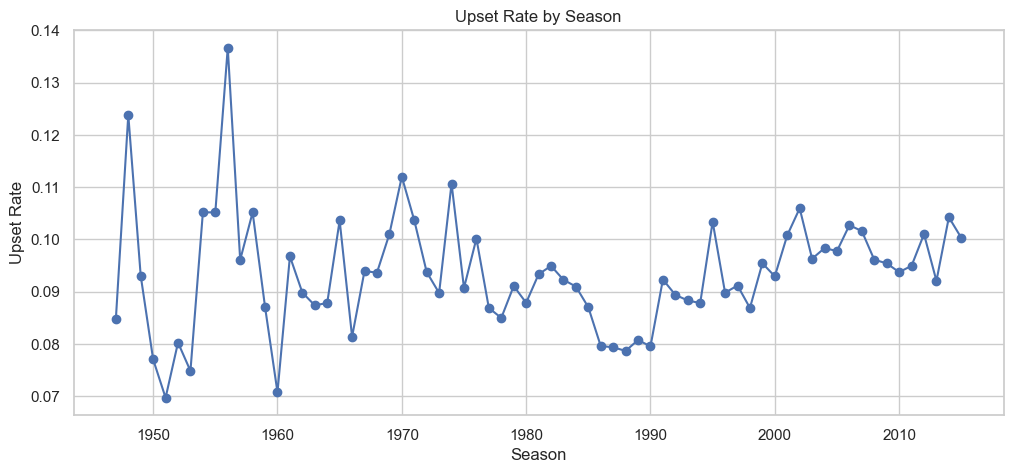

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(yearly_summary["year_id"], yearly_summary["upset_rate"], marker="o")
plt.title("Upset Rate by Season")
plt.xlabel("Season")
plt.ylabel("Upset Rate")
plt.show()

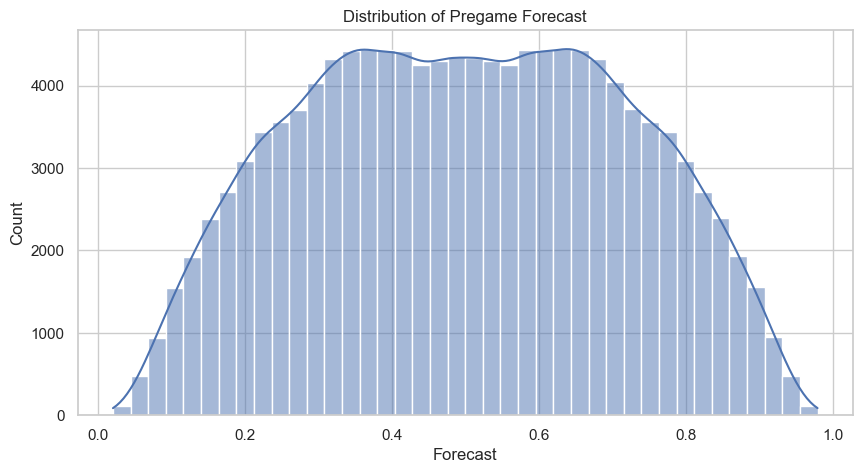

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df["forecast"], bins=40, kde=True)
plt.title("Distribution of Pregame Forecast")
plt.xlabel("Forecast")
plt.ylabel("Count")
plt.show()

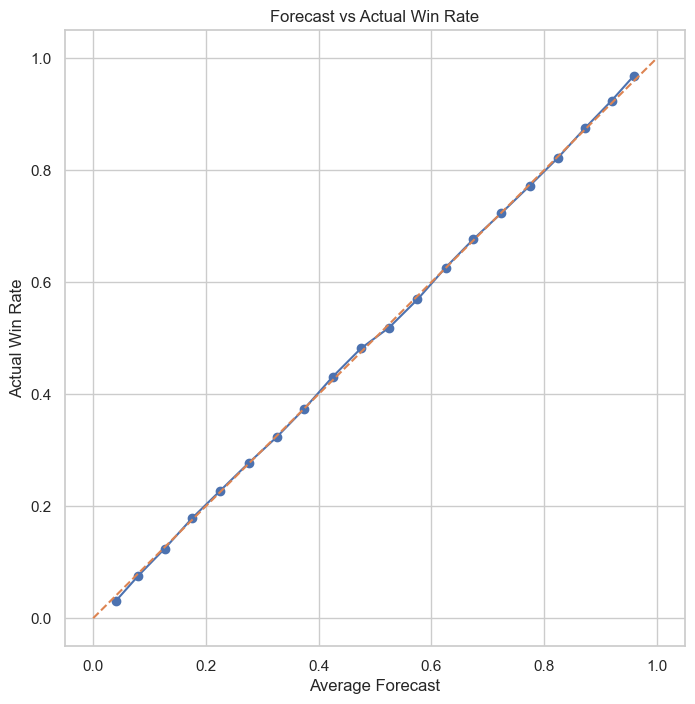

In [22]:
forecast_calibration = (
    df.assign(forecast_bin=pd.cut(df["forecast"], bins=np.linspace(0, 1, 21), include_lowest=True))
      .groupby("forecast_bin")
      .agg(
          avg_forecast=("forecast", "mean"),
          actual_win_rate=("win", "mean"),
          count=("win", "size")
      )
      .dropna()
      .reset_index()
)

plt.figure(figsize=(8, 8))
plt.plot(forecast_calibration["avg_forecast"], forecast_calibration["actual_win_rate"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Forecast vs Actual Win Rate")
plt.xlabel("Average Forecast")
plt.ylabel("Actual Win Rate")
plt.show()

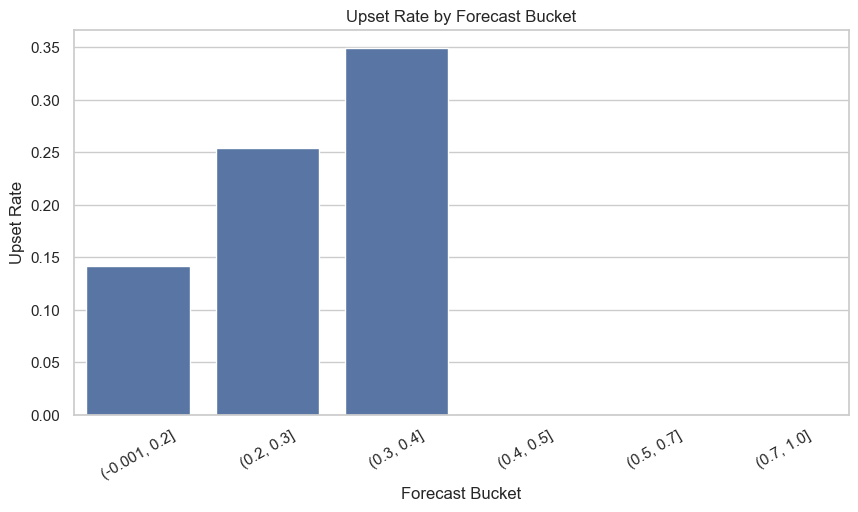

In [23]:
bucket_summary = (
    df.groupby("forecast_bucket")
      .agg(upset_rate=("upset", "mean"), count=("upset", "size"))
      .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=bucket_summary, x="forecast_bucket", y="upset_rate")
plt.xticks(rotation=30)
plt.title("Upset Rate by Forecast Bucket")
plt.xlabel("Forecast Bucket")
plt.ylabel("Upset Rate")
plt.show()

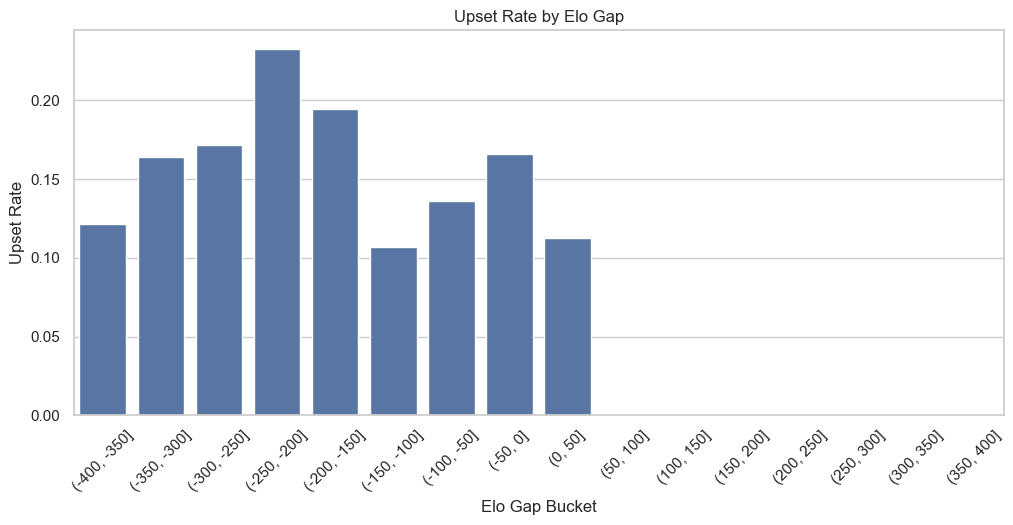

In [32]:
df["elo_gap_bucket"] = pd.cut(df["elo_gap"], bins=np.arange(-400, 401, 50))

elo_gap_summary = (
    df.groupby("elo_gap_bucket", observed=False)
      .agg(
          upset_rate=("upset", "mean"),
          count=("upset", "size")
      )
      .reset_index()
)

elo_gap_summary["elo_gap_bucket"] = elo_gap_summary["elo_gap_bucket"].astype(str)

plt.figure(figsize=(12, 5))
sns.barplot(data=elo_gap_summary, x="elo_gap_bucket", y="upset_rate")
plt.xticks(rotation=45)
plt.title("Upset Rate by Elo Gap")
plt.xlabel("Elo Gap Bucket")
plt.ylabel("Upset Rate")
plt.show()

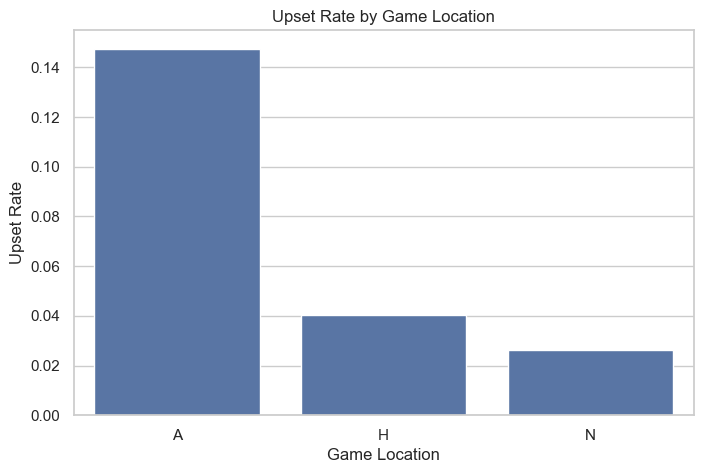

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=location_summary, x="game_location", y="upset_rate")
plt.title("Upset Rate by Game Location")
plt.xlabel("Game Location")
plt.ylabel("Upset Rate")
plt.show()

In [27]:
rolling_cols = [
    "win_rolling_5", "win_rolling_10",
    "pointdiff_rolling_5", "pointdiff_rolling_10",
    "pointdiff_std_10",
    "elo_delta_rolling_5", "elo_delta_rolling_10",
    "opp_elo_rolling_10"
]

print(df[rolling_cols].describe().T)

                         count         mean        std          min  \
win_rolling_5         125784.0     0.500557   0.254621     0.000000   
win_rolling_10        125784.0     0.500590   0.204374     0.000000   
pointdiff_rolling_5   125784.0     0.015999   7.074387   -31.000000   
pointdiff_rolling_10  125784.0     0.016018   5.817916   -22.900000   
pointdiff_std_10      125784.0    12.287520   3.167573     2.149935   
elo_delta_rolling_5   125784.0     0.004811   4.415323   -21.916520   
elo_delta_rolling_10  125784.0     0.004740   3.116769   -13.623860   
opp_elo_rolling_10    125784.0  1495.370094  50.327302  1210.169290   

                              25%          50%          75%          max  
win_rolling_5            0.400000     0.600000     0.600000     1.000000  
win_rolling_10           0.400000     0.500000     0.600000     1.000000  
pointdiff_rolling_5     -4.800000     0.000000     4.800000    31.200000  
pointdiff_rolling_10    -3.900000     0.100000     4.000000 

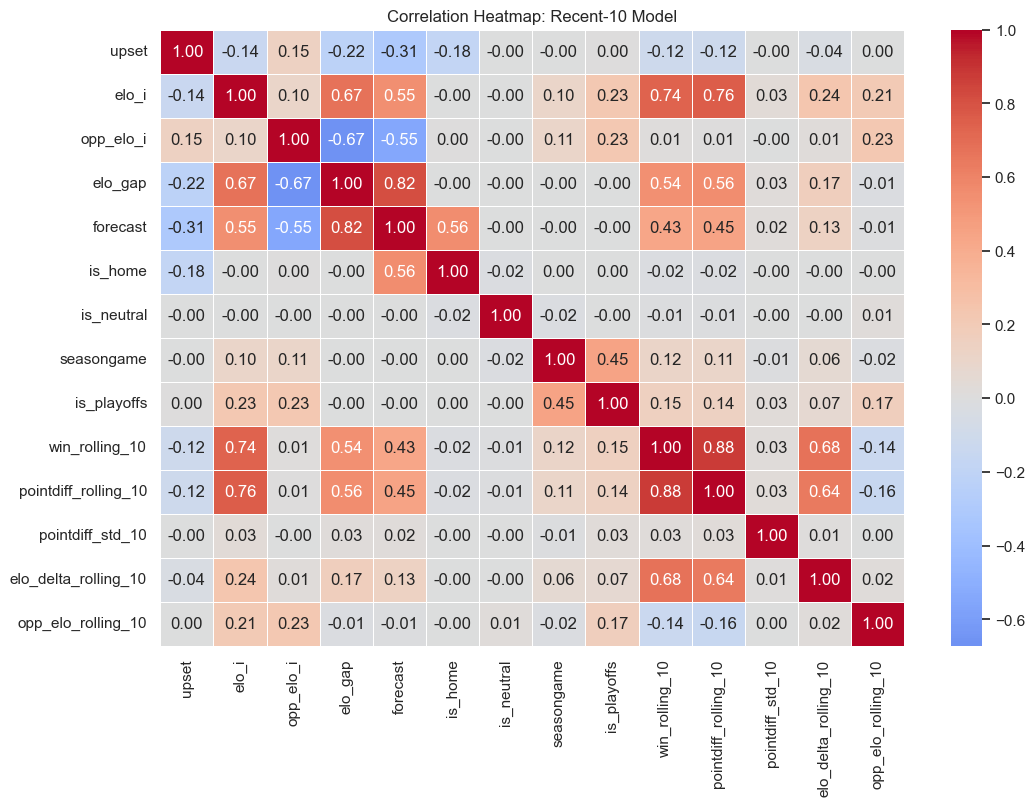

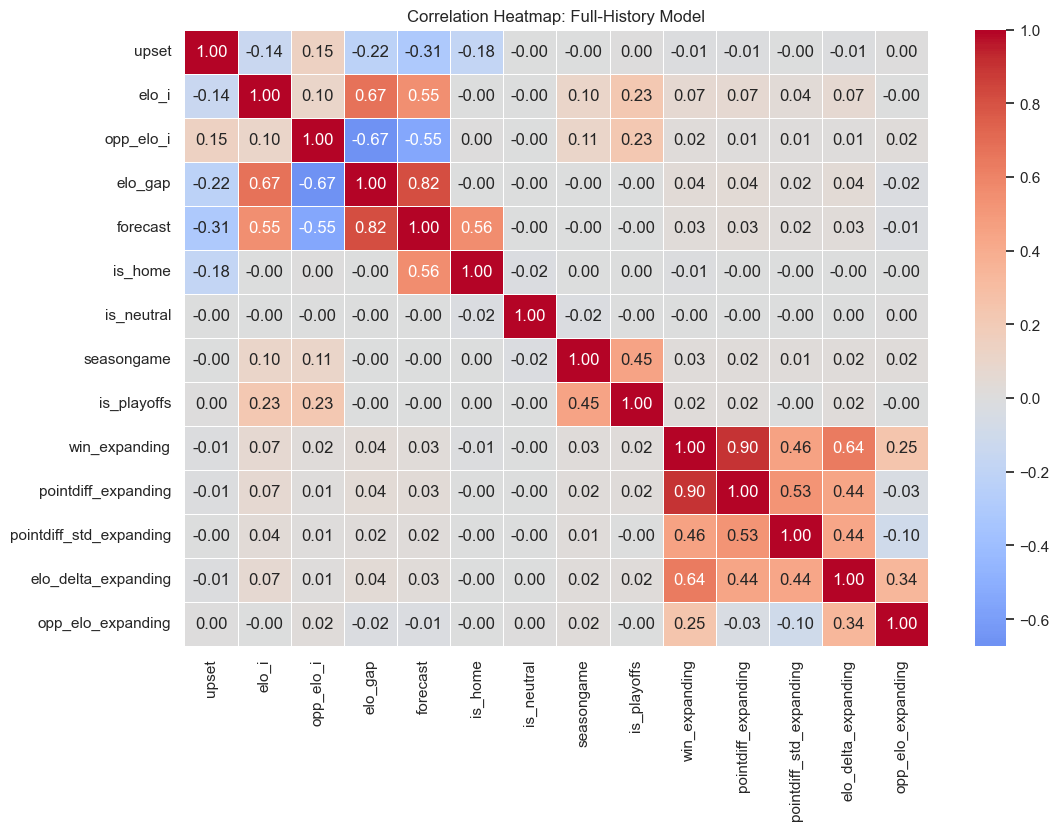

In [41]:
def plot_model_heatmap(data, feature_cols, target_col, title):
    cols = [target_col] + [c for c in feature_cols if c in data.columns]
    corr = data[cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5
    )
    plt.title(title)
    plt.show()


plot_model_heatmap(
    recent_10_plot_df,
    recent_10_model_features,
    target_col,
    "Correlation Heatmap: Recent-10 Model"
)

plot_model_heatmap(
    full_history_plot_df,
    full_history_model_features,
    target_col,
    "Correlation Heatmap: Full-History Model"
)

In [42]:
def make_upset_profile_table(data, feature_cols, target_col):
    profile = (
        data.groupby(target_col)[feature_cols]
            .mean()
            .T
            .rename(columns={0: "non_upset_mean", 1: "upset_mean"})
    )
    profile["difference"] = profile["upset_mean"] - profile["non_upset_mean"]
    return profile.sort_values("difference", ascending=False)


recent_10_profile = make_upset_profile_table(
    recent_10_plot_df, recent_10_model_features, target_col
)
full_history_profile = make_upset_profile_table(
    full_history_plot_df, full_history_model_features, target_col
)

print("Recent-10 model upset profile:")
print(recent_10_profile)

print("\nFull-history model upset profile:")
print(full_history_profile)

Recent-10 model upset profile:
upset                 non_upset_mean   upset_mean  difference
opp_elo_i                1490.297548  1547.708356   57.410808
opp_elo_rolling_10       1495.354781  1495.517992    0.163210
is_playoffs                 0.063790     0.067367    0.003577
is_neutral                  0.000325     0.000085   -0.000240
pointdiff_std_10           12.290013    12.263435   -0.026579
win_rolling_10              0.508199     0.427099   -0.081099
forecast                    0.521664     0.293757   -0.227908
is_home                     0.529351     0.214050   -0.315301
seasongame                 43.725503    43.389628   -0.335875
elo_delta_rolling_10        0.041722    -0.352456   -0.394178
pointdiff_rolling_10        0.231458    -2.064867   -2.296326
elo_i                    1501.137381  1445.775906  -55.361475
elo_gap                    10.839833  -101.932450 -112.772283

Full-history model upset profile:
upset                    non_upset_mean   upset_mean  difference
o

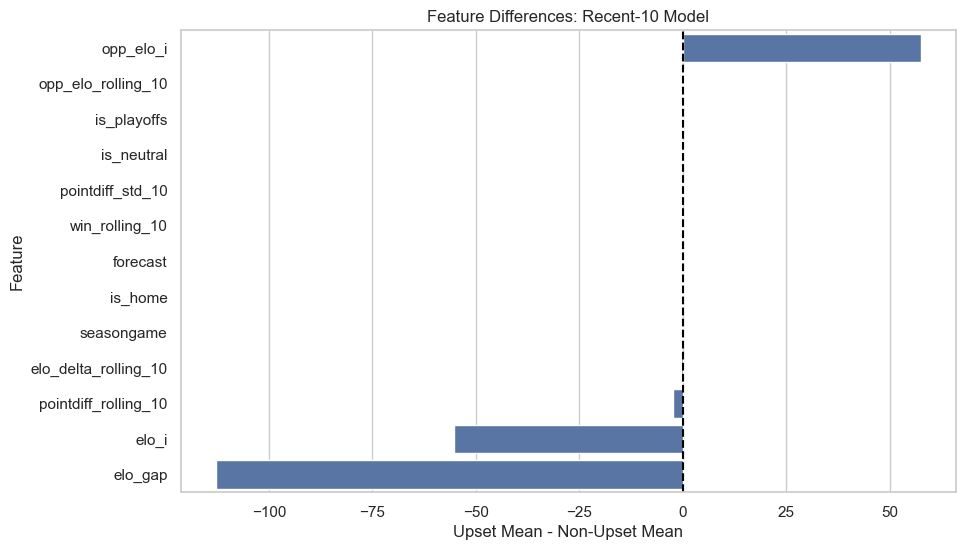

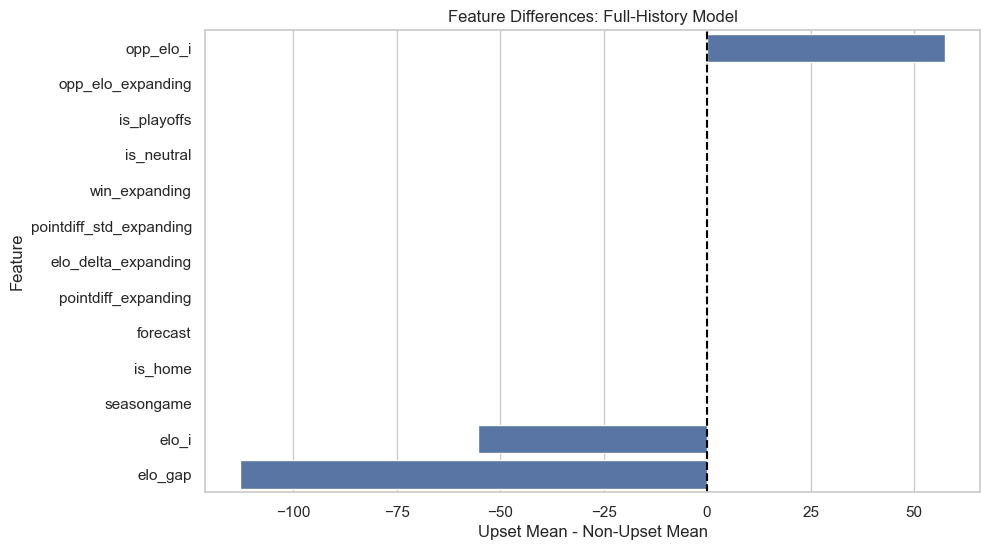

In [43]:
def plot_upset_profile(profile_df, title):
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=profile_df["difference"],
        y=profile_df.index
    )
    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Upset Mean - Non-Upset Mean")
    plt.ylabel("Feature")
    plt.show()


plot_upset_profile(
    recent_10_profile,
    "Feature Differences: Recent-10 Model"
)

plot_upset_profile(
    full_history_profile,
    "Feature Differences: Full-History Model"
)

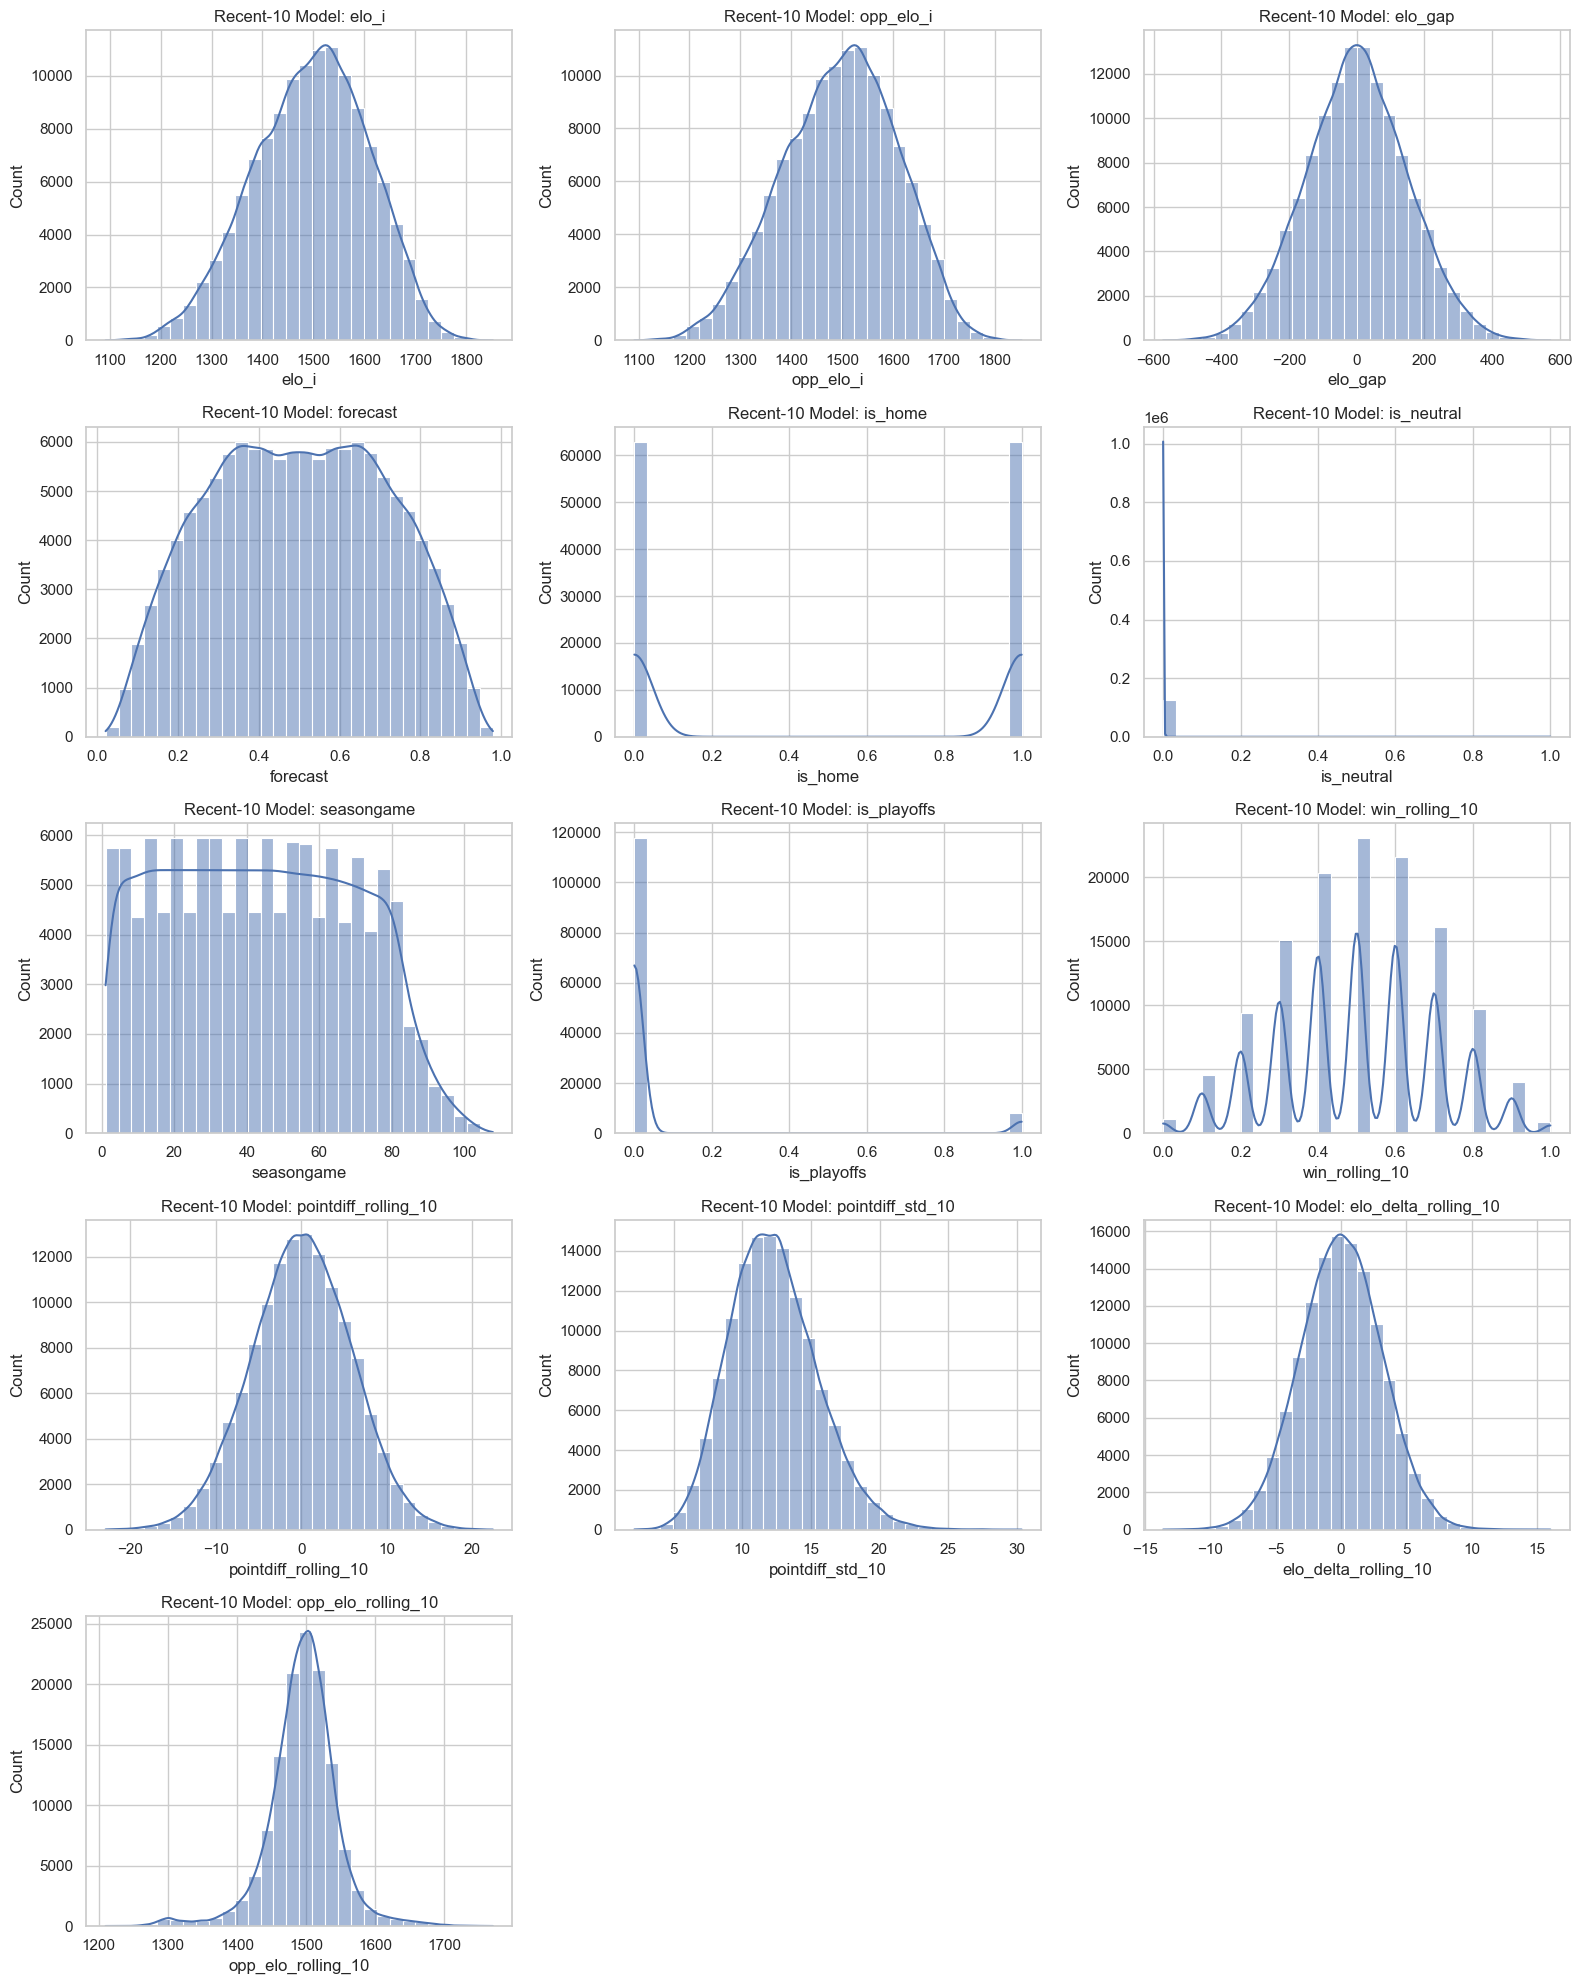

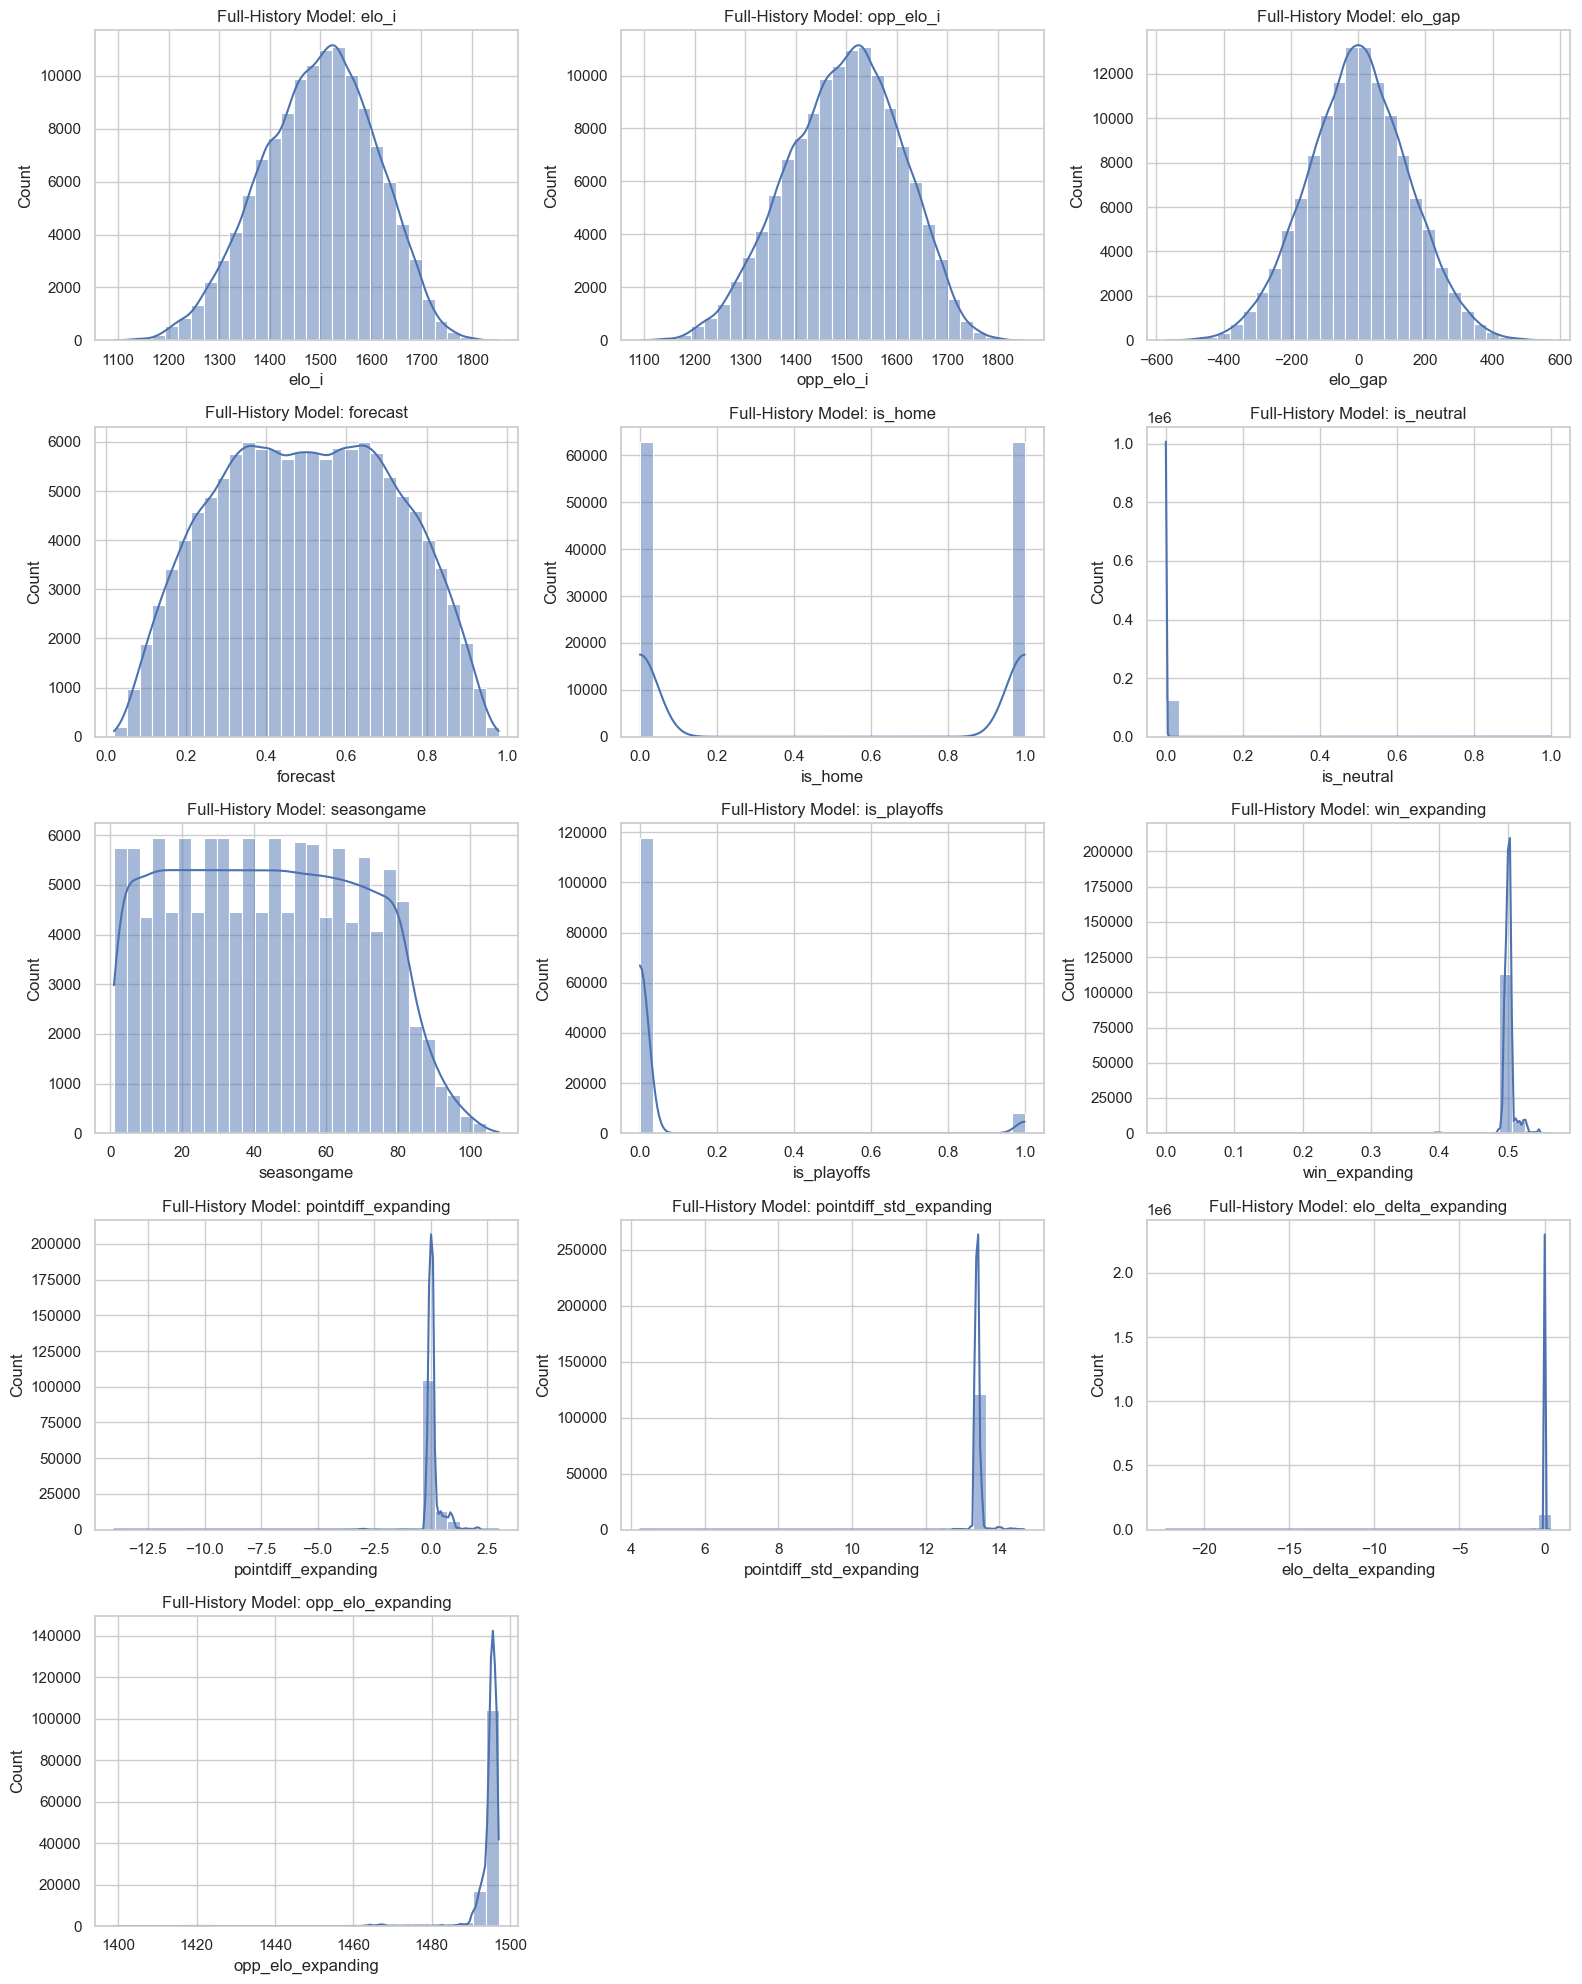

In [45]:
def plot_feature_histograms(data, feature_cols, title_prefix, bins=30):
    n = len(feature_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_cols):
        sns.histplot(data[col], bins=bins, kde=True, ax=axes[i])
        axes[i].set_title(f"{title_prefix}: {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


plot_feature_histograms(
    recent_10_plot_df,
    recent_10_model_features,
    "Recent-10 Model"
)

plot_feature_histograms(
    full_history_plot_df,
    full_history_model_features,
    "Full-History Model"
)

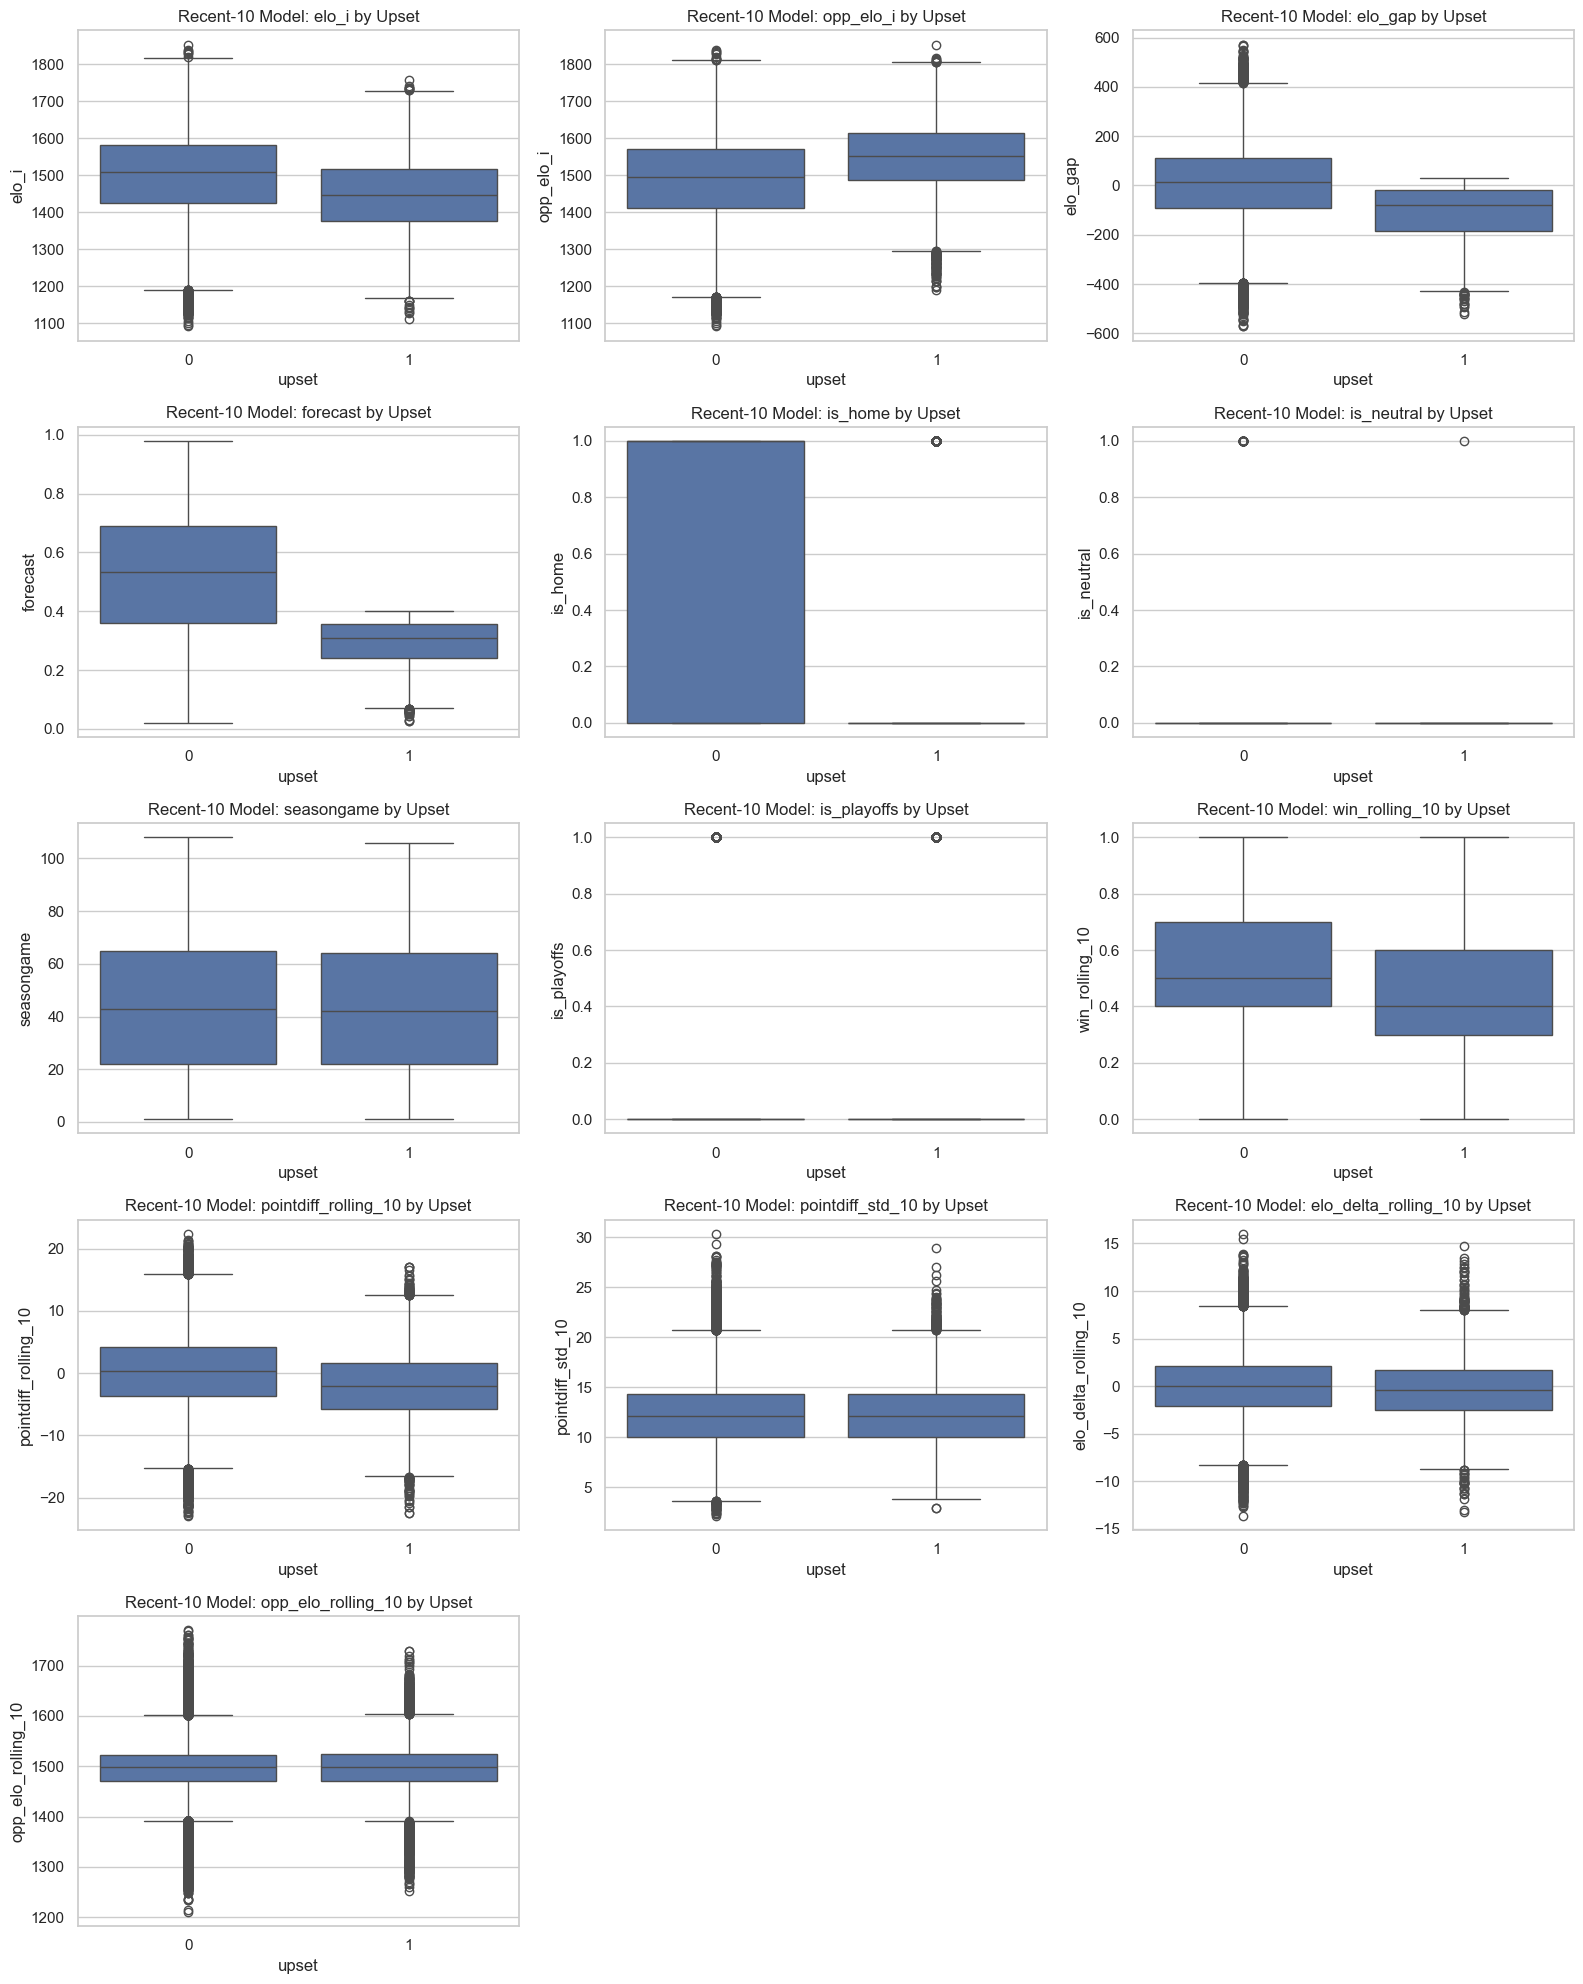

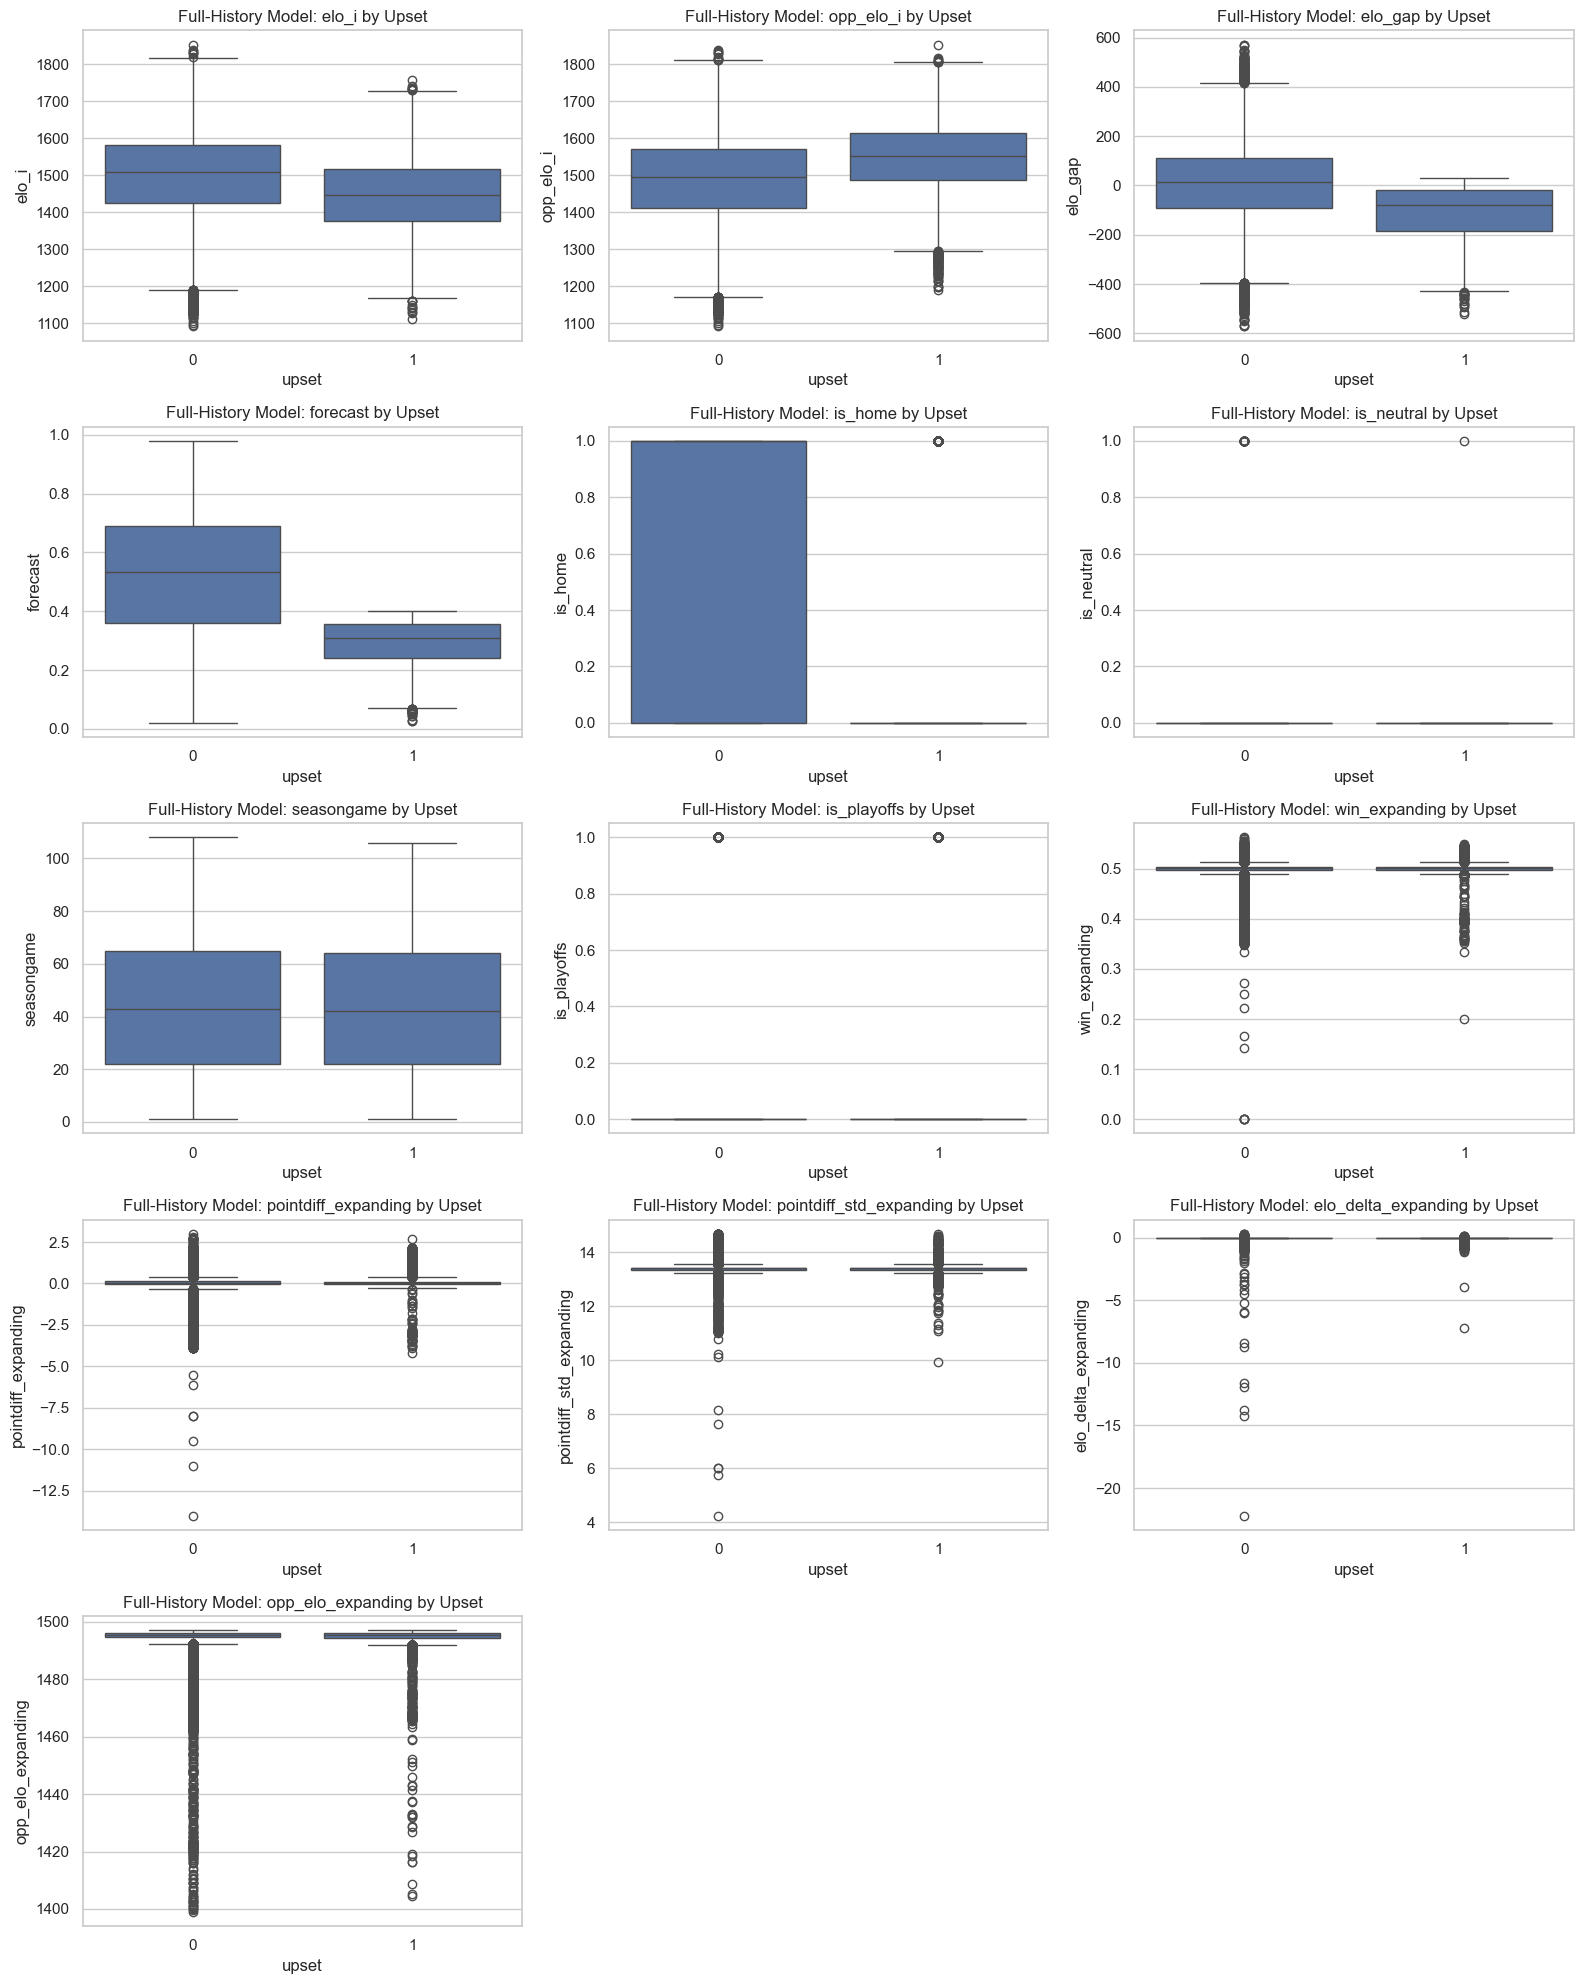

In [46]:
def plot_feature_boxplots(data, feature_cols, target_col, title_prefix):
    n = len(feature_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_cols):
        sns.boxplot(data=data, x=target_col, y=col, ax=axes[i])
        axes[i].set_title(f"{title_prefix}: {col} by Upset")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


plot_feature_boxplots(
    recent_10_plot_df,
    recent_10_model_features,
    target_col,
    "Recent-10 Model"
)

plot_feature_boxplots(
    full_history_plot_df,
    full_history_model_features,
    target_col,
    "Full-History Model"
)

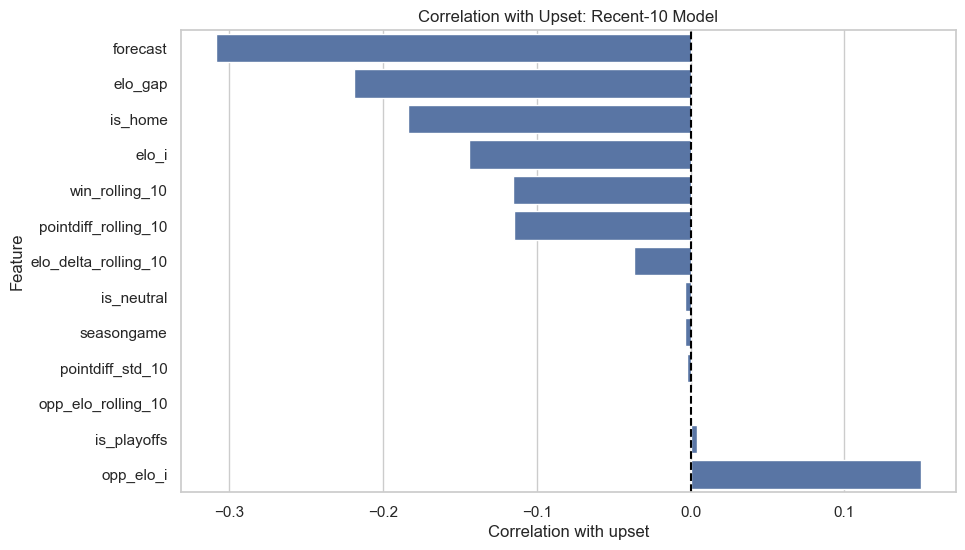

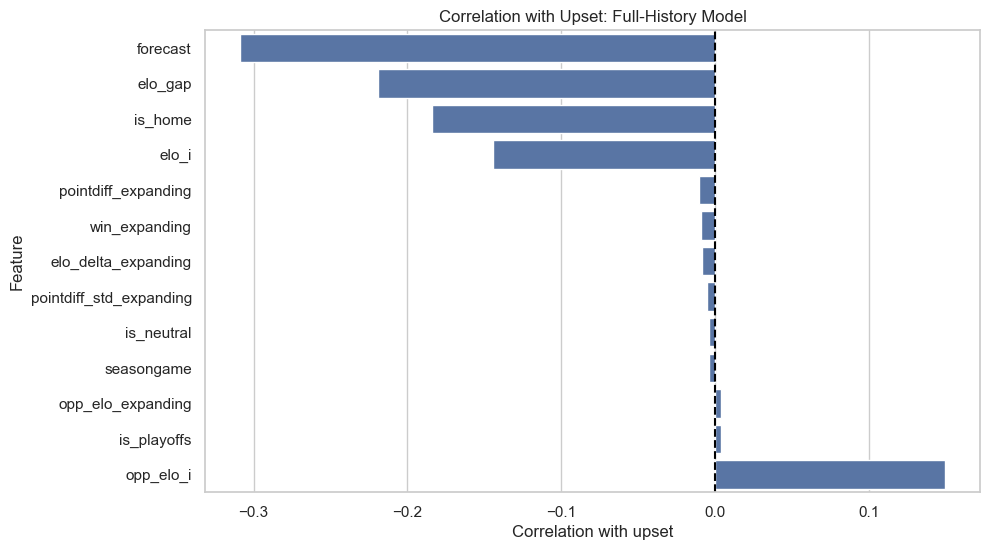

In [47]:
def plot_target_correlations(data, feature_cols, target_col, title):
    corr_with_target = (
        data[[target_col] + feature_cols]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
        .sort_values()
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(x=corr_with_target.values, y=corr_with_target.index)
    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel(f"Correlation with {target_col}")
    plt.ylabel("Feature")
    plt.show()

    return corr_with_target


recent_10_target_corr = plot_target_correlations(
    recent_10_plot_df,
    recent_10_model_features,
    target_col,
    "Correlation with Upset: Recent-10 Model"
)

full_history_target_corr = plot_target_correlations(
    full_history_plot_df,
    full_history_model_features,
    target_col,
    "Correlation with Upset: Full-History Model"
)

In [36]:
# -----------------------------
# MASTER MODELING DATAFRAME
# One big dataframe containing:
# - shared/base features
# - last-10-game features
# - full-history features
# -----------------------------

base_features = [
    "elo_i",
    "opp_elo_i",
    "elo_gap",
    "forecast",
    "is_home",
    "is_neutral",
    "seasongame",
    "is_playoffs",
]

last10_features = [
    "win_rolling_10",
    "pointdiff_rolling_10",
    "pointdiff_std_10",
    "elo_delta_rolling_10",
    "opp_elo_rolling_10",
]

full_history_features = [
    "win_expanding",
    "pointdiff_expanding",
    "pointdiff_std_expanding",
    "elo_delta_expanding",
    "opp_elo_expanding",
]

target_col = "upset"

id_cols = [
    "date_game",
    "year_id",
    "gameorder",
    "game_id",
    "fran_id",
    "team_id",
    "opp_id",
    "opp_fran",
]

# Keep only columns that actually exist
base_features = [c for c in base_features if c in df.columns]
last10_features = [c for c in last10_features if c in df.columns]
full_history_features = [c for c in full_history_features if c in df.columns]
id_cols = [c for c in id_cols if c in df.columns]

all_model_features = base_features + last10_features + full_history_features

master_model_df = df[id_cols + [target_col] + all_model_features].copy()

# Final chronological sort
master_model_df = master_model_df.sort_values(["date_game", "gameorder", "game_id"]).reset_index(drop=True)

print("Master modeling dataframe shape:", master_model_df.shape)
print("\nColumns:")
print(master_model_df.columns.tolist())

print("\nPreview:")
print(master_model_df.head())

Master modeling dataframe shape: (125784, 27)

Columns:
['date_game', 'year_id', 'gameorder', 'game_id', 'fran_id', 'team_id', 'opp_id', 'opp_fran', 'upset', 'elo_i', 'opp_elo_i', 'elo_gap', 'forecast', 'is_home', 'is_neutral', 'seasongame', 'is_playoffs', 'win_rolling_10', 'pointdiff_rolling_10', 'pointdiff_std_10', 'elo_delta_rolling_10', 'opp_elo_rolling_10', 'win_expanding', 'pointdiff_expanding', 'pointdiff_std_expanding', 'elo_delta_expanding', 'opp_elo_expanding']

Preview:
   date_game  year_id  gameorder       game_id  fran_id team_id opp_id  \
0 1946-11-24     1947         47  194611240CHS    Stags     CHS    DTF   
1 1946-11-26     1947         51  194611260DTF  Falcons     DTF    CLR   
2 1946-11-26     1947         52  194611260GSW  Celtics     BOS    PHW   
3 1946-11-26     1947         53  194611260TRH  Huskies     TRH    WSC   
4 1946-11-27     1947         54  194611270NYK  Bombers     STB    NYK   

   opp_fran  upset      elo_i  ...  win_rolling_10  pointdiff_rolling

In [37]:
recent_10_model_features = base_features + last10_features
full_history_model_features = base_features + full_history_features

print("Recent-10 model features:")
print(recent_10_model_features)

print("\nFull-history model features:")
print(full_history_model_features)

Recent-10 model features:
['elo_i', 'opp_elo_i', 'elo_gap', 'forecast', 'is_home', 'is_neutral', 'seasongame', 'is_playoffs', 'win_rolling_10', 'pointdiff_rolling_10', 'pointdiff_std_10', 'elo_delta_rolling_10', 'opp_elo_rolling_10']

Full-history model features:
['elo_i', 'opp_elo_i', 'elo_gap', 'forecast', 'is_home', 'is_neutral', 'seasongame', 'is_playoffs', 'win_expanding', 'pointdiff_expanding', 'pointdiff_std_expanding', 'elo_delta_expanding', 'opp_elo_expanding']
